## Problem Statement

Given a salary dataset with years of experience and the corresponding salary, use an ML model to predict new salary of people based on some different years of experience.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
ds = pd.read_csv("data/Salary_Data.csv")
ds.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [10]:
X = ds["YearsExperience"].values
Y = ds["Salary"].values

In [11]:
X

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [12]:
Y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

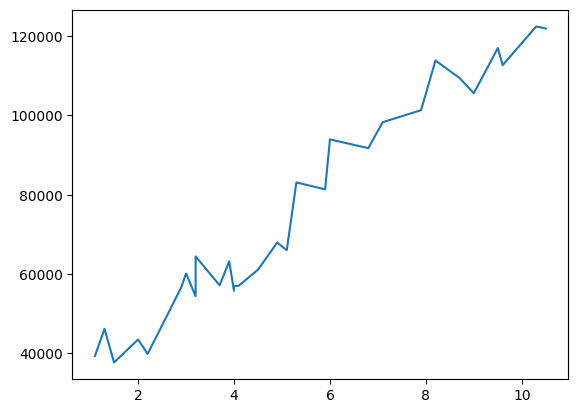

In [13]:
# Imp step to know which algorithm to use
plt.plot(X, Y)

Conversion to numpy array

In [14]:
# This is Redundant 
X = np.array(X)
Y = np.array(Y)

Normalisation of the dataset

In [15]:
def mean(X):
    return np.sum(X)/len(X)

1.  (x-mean) = deviation  
2.  **2 = square  
3.  sum = total spread  
4.  /n = average -> population variance  
5.  /n-1 = sample variance  


In [17]:
# Population variance
def variance(X):
    mean_value = mean(X)
    return np.sum((X-mean_value)**2)/len(X)

(X - mean) / std

In [19]:
# z-score normailzation
def norm(X):
    mean_value = mean(X)
    variance_value = variance(X)
    return (X - mean_value)/np.sqrt(variance_value)

In [20]:
X_norm = norm(X)
X_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

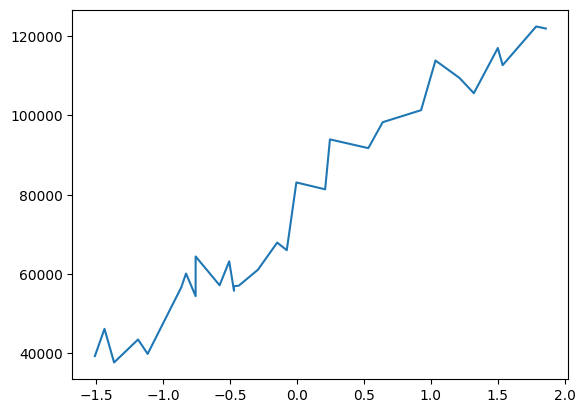

In [21]:
plt.plot(X_norm, Y)

learning rate, max iterations, threshold value.
weight a and bias b 

In [22]:
import random

In [23]:
class SimpleLR:
    def __init__(self, lr=0.1, max_iter=2000, threshold=1e-6):
        self.lr = lr                                # learning rate
        self.max_iter = max_iter                    # max training steps
        self.threshold = threshold                  # stopping condition
        self.weight = random.uniform(-1,1)
        self.bias = random.uniform(-1,1)

    def predict(self, X):
        return self.weight*X + self.bias            # w * x + b

    # Return loss history and help us understand how losses are performing.
    def fit(self, X, Y):

        n = len(X)
        loss_history = []

        y_pred = self.predict(X)
        errors = Y-y_pred

        prev_loss = (1/(2*n)) * np.sum(errors**2)   # Mean Squared Error - cost function
        loss_history.append(prev_loss)

        for i in range(self.max_iter):

            w_grad = (1/n) * np.sum(errors*X)
            b_grad = (1/n) * np.sum(errors)

            self.weight += self.lr * w_grad
            self.bias += self.lr * b_grad

            y_pred = self.predict(X)
            errors = Y-y_pred

            curr_loss = (1/(2*n)) * np.sum(errors**2)   # new loss

            if np.abs(curr_loss - prev_loss) < self.threshold:  # stopping conditions
                break
            prev_loss = curr_loss
            loss_history.append(curr_loss)
        return loss_history

    def plot(self, X, Y):
        y_pred = self.predict(X)
        plt.plot(X, Y)
        plt.plot(X, y_pred)

In [24]:
model = SimpleLR()

In [25]:
loss_history = model.fit(X_norm, Y)

In [26]:
loss_history

[np.float64(3251470481.434211),
 np.float64(2636661830.3753266),
 np.float64(2138666823.0176318),
 np.float64(1735290867.0578978),
 np.float64(1408556342.730514),
 np.float64(1143901378.0253332),
 np.float64(929530856.6141363),
 np.float64(755890734.2710673),
 np.float64(615242235.1731812),
 np.float64(501316950.90389335),
 np.float64(409037470.64577025),
 np.float64(334291091.63669056),
 np.float64(273746524.639336),
 np.float64(224705425.37147877),
 np.float64(184982134.9645145),
 np.float64(152806269.73487344),
 np.float64(126743818.89886425),
 np.float64(105633233.7216968),
 np.float64(88533659.72819106),
 np.float64(74683004.79345137),
 np.float64(63463974.29631228),
 np.float64(54376559.59362972),
 np.float64(47015753.68445678),
 np.float64(41053500.89802669),
 np.float64(36224076.14101831),
 np.float64(32312242.08784156),
 np.float64(29143656.504768353),
 np.float64(26577102.18247907),
 np.float64(24498193.181424703),
 np.float64(22814276.890570723),
 np.float64(21450304.6949789

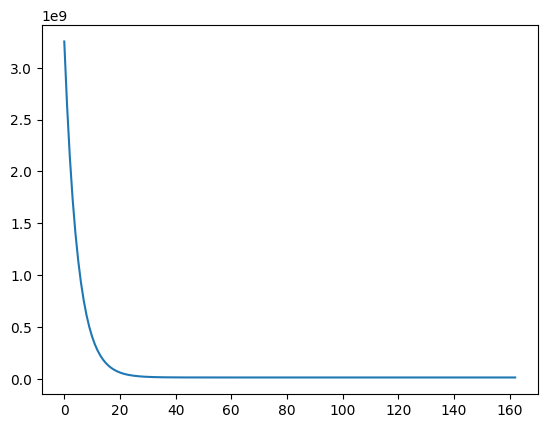

In [27]:
plt.plot(loss_history)

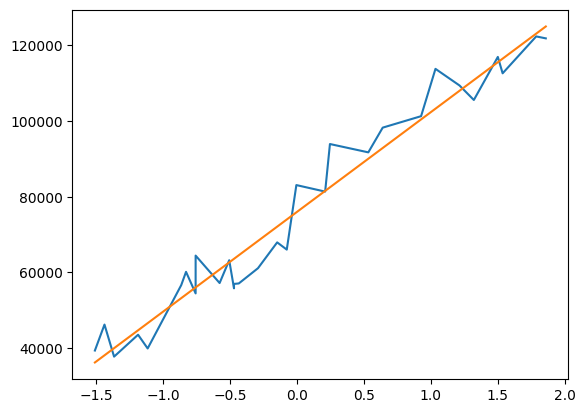

In [28]:
model.plot(X_norm, Y)